# Self-Supervised (SimCLR) Pretraining for YOLOv5 Backbones (Ultralytics)

**You only need to set `UNLABELED_DIR`** to a folder that contains your images (subfolders are OK).

> Notes:
> - The paper uses strong SimCLR-style augmentations, NT-Xent with **temperature τ=0.1**, cosine LR schedule, and ~200 epochs on large-scale data. Adjust epochs/batch size for your dataset/GPU.  




In [1]:
# === (1) Install deps (Colab / fresh env) ===

!pip -q install --upgrade ultralytics torch torchvision opencv-python tqdm


In [4]:
!pip -q install --upgrade opencv-python tqdm

✅ Success! Image Shape: (512, 512) | Data Type: uint8


[ WARN:0@9.574] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50838 (0xc696) encountered
[ WARN:0@9.574] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50839 (0xc697) encountered


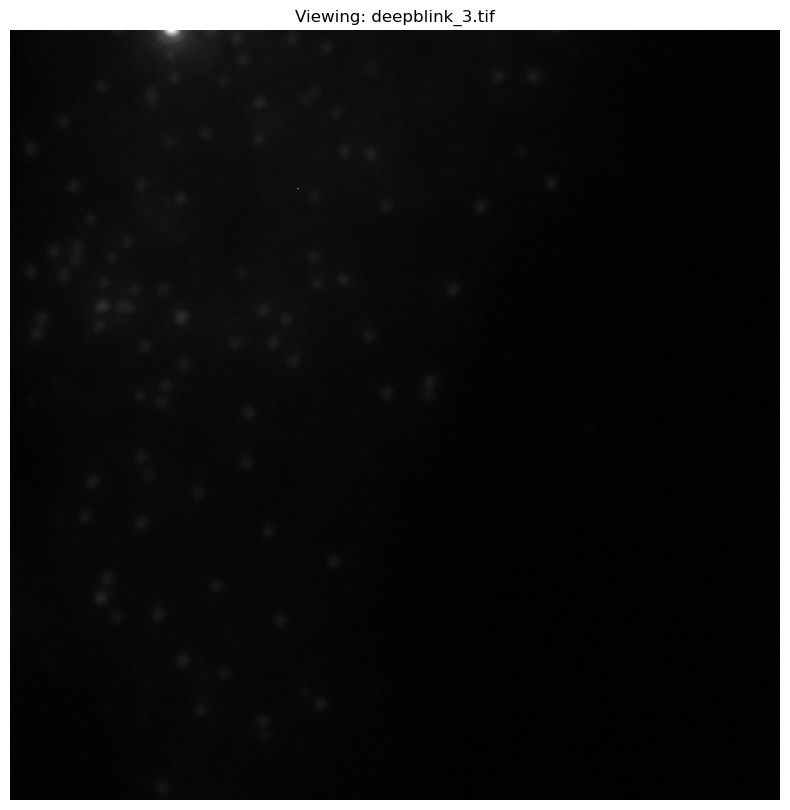

In [3]:
import cv2
import matplotlib.pyplot as plt
import os

# 1. Use the absolute path with the leading slash
file_path = '/home/cvpr_ug_4/saaransh/FISH_spots/2d/image/deepblink_3.tif'

# 2. Check if the file exists on the disk
if not os.path.exists(file_path):
    print(f"❌ Error: File not found at {file_path}")
else:
    # 3. Read the image
    # For scientific TIFFs, we use IMREAD_UNCHANGED to keep the original bit-depth
    img = cv2.imread(file_path, cv2.IMREAD_UNCHANGED)

    # 4. Check if the image is valid (Not None)
    if img is None:
        print("❌ Error: cv2.imread returned None.")
        # Check if it's still an LFS pointer
        with open(file_path, 'r') as f:
            content = f.read(100)
            if "git-lfs" in content:
                print("⚠️ REASON: The file is still a Git LFS text pointer. Run 'git lfs pull' in your terminal.")
            else:
                print("⚠️ REASON: The file might be a corrupted TIFF or an unsupported format.")
    else:
        # 5. Display the image
        print(f"✅ Success! Image Shape: {img.shape} | Data Type: {img.dtype}")
        
        plt.figure(figsize=(10, 10))
        
        # If the image is grayscale (typical for FISH), use gray colormap
        if len(img.shape) == 2:
            plt.imshow(img, cmap='gray')
        else:
            # OpenCV loads color as BGR, Matplotlib needs RGB
            img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            plt.imshow(img_rgb)
            
        plt.title(f"Viewing: {os.path.basename(file_path)}")
        plt.axis('off')
        plt.show()

# patching

In [5]:
import os
from pathlib import Path

# --- CONFIGURATION ---
# We are in 'srija/code', so we go up one level (..) to 'srija'
# Then we create 'D-DISH_PATCH'
OUTPUT_DIR = Path("../FISH_PATCH")

# --- ACTION ---
try:
    # parents=True creates any missing parent folders
    # exist_ok=True means it won't crash if the folder already exists
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    
    print(f"✅ Success! Folder created at:")
    print(f"   {OUTPUT_DIR.resolve()}")
    
except Exception as e:
    print(f"❌ Error creating folder: {e}")

✅ Success! Folder created at:
   /home/cvpr_ug_4/saaransh/FISH_PATCH


In [6]:
import os
import cv2
from pathlib import Path
from tqdm.auto import tqdm

# --- CONFIGURATION ---
# 1. Paths relative to where you are running the script (srija/code)
INPUT_DIR = Path("/home/cvpr_ug_4/saaransh/FISH_spots/2d/image") 
OUTPUT_DIR = Path("../FISH_PATCH")

# 2. Patch settings
PATCH_SIZE = 256
STRIDE = 256  # Set to 256 for non-overlapping patches (grid style)

# --- SETUP ---
# Create the output folder if it doesn't exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
img_extensions = {".tif", ".tiff"}

# Verify input folder
if not INPUT_DIR.exists():
    raise FileNotFoundError(f"❌ Error: Input directory not found at {INPUT_DIR.resolve()}")

print(f"📂 Reading images from: {INPUT_DIR.resolve()}")
print(f"💾 Saving patches to:   {OUTPUT_DIR.resolve()}")

# --- MAIN LOOP ---
# Find all tiff files recursively
image_paths = [p for p in INPUT_DIR.rglob("*") if p.suffix.lower() in img_extensions]
print(f"   Found {len(image_paths)} large images to process.")

total_patches = 0

for img_path in tqdm(image_paths, desc="Patching"):
    try:
        # 1. Read the image using OpenCV
        img = cv2.imread(str(img_path))
        
        if img is None:
            print(f"⚠️ Warning: Could not open {img_path.name}. Skipping.")
            continue
            
        # Get dimensions
        img_h, img_w, _ = img.shape
        
        # 2. Iterate through the image (Grid Logic)
        # We stop early (img_h - PATCH_SIZE) to strictly avoid partial patches at edges
        for y in range(0, img_h - PATCH_SIZE + 1, STRIDE):
            for x in range(0, img_w - PATCH_SIZE + 1, STRIDE):
                
                # 3. Crop
                patch = img[y : y + PATCH_SIZE, x : x + PATCH_SIZE]
                
                # 4. Save
                # Naming format: OriginalName_Y_X.tif (helps track location)
                patch_name = f"{img_path.stem}_y{y}_x{x}.tif"
                save_path = OUTPUT_DIR / patch_name
                
                cv2.imwrite(str(save_path), patch)
                total_patches += 1
                
    except Exception as e:
        print(f"❌ Error processing {img_path.name}: {e}")

print("-" * 40)
print(f"✅ Done! Created {total_patches} patches in 'FISH_PATCH'.")

📂 Reading images from: /home/cvpr_ug_4/saaransh/FISH_spots/2d/image
💾 Saving patches to:   /home/cvpr_ug_4/saaransh/FISH_PATCH
   Found 4166 large images to process.


Patching:   0%|          | 0/4166 [00:00<?, ?it/s]

[ WARN:0@120.679] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50838 (0xc696) encountered
[ WARN:0@120.679] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50839 (0xc697) encountered
[ WARN:0@120.779] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50838 (0xc696) encountered
[ WARN:0@120.779] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50839 (0xc697) encountered
[ WARN:0@120.905] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50838 (0xc696) encountered
[ WARN:0@120.905] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50839 (0xc697) encountered
[ WARN:0@121.155] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50838 (0xc696) encountered
[ WARN:0@121.155] global grfmt_tiff.cpp:122 TIFF_Warning TIFFReadDirectory: Unknown field with tag 50839 (0xc697) enco

----------------------------------------
✅ Done! Created 16664 patches in 'FISH_PATCH'.


## Imports + configuration

In [7]:
import os, glob, random, math, time
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from torchvision import transforms
from ultralytics import YOLO

# Repro (best-effort)
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
seed_everything(42)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


## Point to your unlabeled dataset folder

In [8]:
#UNLABELED_DIR = r"srija/D-DISH_F"   <-- change
# INCORRECT (because you are already inside 'srija')
# UNLABELED_DIR = r"srija/D-DISH_F"

# CORRECT
UNLABELED_DIR = r"../FISH_PATCH"
# Image size for SimCLR pretraining (paper uses strong random crop/resize; 224 is typical for SimCLR).
IMG_SIZE = 224

YOLO_VARIANT = "yolov5m"  #yolov8s

# Init for pretraining:
# - "random": starts from YOLOv8 architecture init (pure SSL on your data)
# - "coco":   starts from COCO-supervised weights, then does SSL on your data (often helps, but less "pure")
INIT = "random"  

# Training knobs
EPOCHS = 300 #50               
BATCH_SIZE = 32           
GRAD_ACCUM_STEPS = 1      
BASE_LR = 1e-1 #0.3             
WEIGHT_DECAY = 1e-4
TEMPERATURE = 0.5 #0.1        
NUM_WORKERS = 2

OUT_DIR = Path("./ssl_yolov5_outputs_one")
OUT_DIR.mkdir(parents=True, exist_ok=True)

print("OUT_DIR:", OUT_DIR.resolve())


OUT_DIR: /home/cvpr_ug_4/saaransh/Backend_Pipeline/ssl_yolov5_outputs_one


In [9]:
#ADDED EXTRA




UNLABELED_DIR = r"../FISH_PATCH"
import os
from pathlib import Path

# 1. Define the path using "../" to go up one level from 'code'
target_folder = Path("../FISH_PATCH")

# 2. Check if it exists
print(f"Current Directory: {Path.cwd()}")
print(f"Looking for data at: {target_folder.resolve()}")

if not target_folder.exists():
    print(f"\n❌ ERROR: Could not find '{target_folder.name}'.")
    print("   Check: Is the folder named 'D-DISH' or 'D-DISH_F'? (Check spelling carefully)")
    
    # Auto-check for the alternative name seen in your first screenshot
    alt_folder = Path("../FISH")
    if alt_folder.exists():
        print(f"   💡 Found '{alt_folder.name}' instead! Update your code to: UNLABELED_DIR = r'../FISH'")
else:
    print(f"✅ SUCCESS: Found '{target_folder.name}'!")
    
    # 3. Count images
    IMG_EXTS = {".tif", ".tiff"}
    all_images = [p for p in target_folder.rglob("*") if p.suffix.lower() in IMG_EXTS]
    
    print(f"   Found {len(all_images)} images inside.")
    if len(all_images) > 0:
        print(f"   Sample: {all_images[0].name}")

Current Directory: /home/cvpr_ug_4/saaransh/Backend_Pipeline
Looking for data at: /home/cvpr_ug_4/saaransh/FISH_PATCH
✅ SUCCESS: Found 'FISH_PATCH'!
   Found 16664 images inside.
   Sample: ExSeq_102_y0_x0.tif


## Dataset: recursively load images from a folder

In [10]:
IMG_EXTS = {".jpg",".jpeg",".png",".bmp",".tif",".tiff",".webp"}

def list_images(root: str):
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"UNLABELED_DIR not found: {root}")
    paths = [p for p in root.rglob("*") if p.suffix.lower() in IMG_EXTS]
    if len(paths) == 0:
        raise RuntimeError(f"No images found under: {root}")
    return paths

all_imgs = list_images(UNLABELED_DIR)
print("Found images:", len(all_imgs))
print("Example:", all_imgs[0])


Found images: 16664
Example: ../FISH_PATCH/ExSeq_102_y0_x0.tif


## SimCLR-style augmentations (strong)

In [11]:
class GaussianBlur(object):
    """SimCLR-style Gaussian blur."""
    def __init__(self, p=0.5, kernel_size=23, sigma=(0.1, 2.0)):
        self.p = p
        self.kernel_size = kernel_size
        self.sigma = sigma

    def __call__(self, img):
        if random.random() > self.p:
            return img
        # PIL filter-based blur (portable)
        from PIL import ImageFilter
        s = random.uniform(self.sigma[0], self.sigma[1])
        return img.filter(ImageFilter.GaussianBlur(radius=s))

# SimCLR augmentation pipeline (random crop/resize, jitter, grayscale, blur, flip)
color_jitter = transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)

# Update your transform slightly to be more aggressive
simclr_transform = transforms.Compose([
    # Lower bound 0.2 means it can zoom in very close, creating harder examples
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.2, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomApply([color_jitter], p=0.8),
    transforms.RandomGrayscale(p=0.2),
    GaussianBlur(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

class TwoCropsTransform:
    def __init__(self, base_transform):
        self.base_transform = base_transform
    def __call__(self, x):
        return self.base_transform(x), self.base_transform(x)

two_view_transform = TwoCropsTransform(simclr_transform)


### Quick visual sanity-check: original vs two augmented views

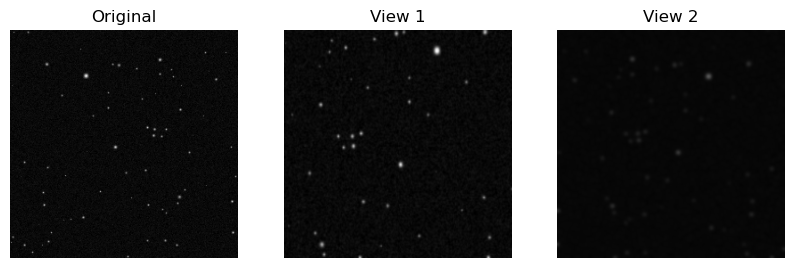

In [12]:
def denorm(t):
    mean = torch.tensor([0.485, 0.456, 0.406])[:, None, None]
    std  = torch.tensor([0.229, 0.224, 0.225])[:, None, None]
    x = (t.cpu() * std + mean).clamp(0, 1)
    return x.permute(1,2,0).numpy()

idx = random.randint(0, len(all_imgs)-1)
img_path = all_imgs[idx]
img = Image.open(img_path).convert("RGB")
v1, v2 = two_view_transform(img)

plt.figure(figsize=(10,3))
plt.subplot(1,3,1); plt.title("Original"); plt.imshow(img); plt.axis("off")
plt.subplot(1,3,2); plt.title("View 1");  plt.imshow(denorm(v1)); plt.axis("off")
plt.subplot(1,3,3); plt.title("View 2");  plt.imshow(denorm(v2)); plt.axis("off")
plt.show()


## DataLoader

In [18]:
class UnlabeledImageFolder(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        p = self.image_paths[idx]
        img = Image.open(p).convert("RGB")
        if self.transform is not None:
            x1, x2 = self.transform(img)
        else:
            x1, x2 = img, img
        return x1, x2

print(f"Number of images found: {len(all_imgs)}")
ds = UnlabeledImageFolder(all_imgs, transform=two_view_transform)

dl = DataLoader(
    ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,  # (for SimCLR) consistent batch sizes
)

print("Batches / epoch:", len(dl))


Number of images found: 16664
Batches / epoch: 520


## Build YOLOv5 encoder (truncate before detection head) + projection MLP

In [19]:
def build_truncated_yolov5(variant: str = "yolov5m", init: str = "random"):
    """
    Returns a YOLOv5 model with the backbone extracted.
    """
    if init not in {"random","coco"}:
        raise ValueError("init must be 'random' or 'coco'")

    # Load the base model
    if init == "coco":
        y = YOLO(f"{variant}.pt")  
    else:
        y = YOLO(f"{variant}.yaml") 

    # Extract the backbone (Layers 0-9 in YOLOv5)
    # This includes the SPPF layer which is standard for feature extraction
    m = nn.Sequential(*list(y.model.model.children())[:10])
    
    return m

# def build_truncated_yolov8(variant: str = "yolov8m", init: str = "random"):   #yolov8s
#     """
#     Returns a YOLOv8 model with the Detect head replaced by Identity.
#     Crucially, it attaches the required '.f' attributes so the Ultralytics 
#     forward pass (which relies on layer metadata) doesn't crash.
#     """
#     if init not in {"random","coco"}:
#         raise ValueError("init must be 'random' or 'coco'")

#     if init == "coco":
#         y = YOLO(f"{variant}.pt")  
#     else:
#         y = YOLO(f"{variant}.yaml") 

#     m = y.model  #(DetectionModel)
    
#     # --- THE FIX ---
#     # 1. Grab the original Detect head
#     orig_head = m.model[-1]
    
#     # 2. Create the replacement layer
#     replacement = nn.Identity()
    
#     # 3. CRITICAL: Copy the routing attributes (.f and .i) from the original head
#     # The 'f' attribute tells YOLO which previous layers feed into this one (e.g., [15, 18, 21])
#     replacement.f = orig_head.f  
#     replacement.i = orig_head.i
    
#     # 4. Perform the swap
#     m.model[-1] = replacement
    
#     return m

class ProjectionMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=2048, out_dim=128):
        super().__init__()
        # 3-Layer MLP with BatchNorm (Standard for high-performance SimCLR)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            
            nn.Linear(hidden_dim, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(inplace=True),
            
            nn.Linear(hidden_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim) # Final BN is often helpful in SimCLR
        )

    def forward(self, x):
        return self.net(x)

class SimCLRYOLOv5(nn.Module):
    def __init__(self, yolo_truncated: nn.Module, proj_dim=128, proj_hidden=2048):
        super().__init__()
        self.encoder = yolo_truncated
        self.pool = nn.AdaptiveAvgPool2d(1)

        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE)
            feats = self.encoder(dummy)
            if isinstance(feats, (list, tuple)):
                f = feats[-1]
            else:
                f = feats
            c = f.shape[1]

        self.proj = ProjectionMLP(c, hidden_dim=proj_hidden, out_dim=proj_dim)

    def forward(self, x):
        feats = self.encoder(x)
        f = feats[-1] if isinstance(feats, (list, tuple)) else feats  # deepest feature map
        h = self.pool(f).flatten(1)
        z = self.proj(h)
        z = F.normalize(z, dim=1)
        return z

# Re-build the truncated YOLO body
yolo_trunc = build_truncated_yolov5(YOLO_VARIANT, INIT)

# Initialize with the new Deeper Projection Head
model = SimCLRYOLOv5(yolo_trunc, proj_dim=128, proj_hidden=2048).to(DEVICE)

print(model)


SimCLRYOLOv5(
  (encoder): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 48, kernel_size=(6, 6), stride=(2, 2), padding=(2, 2), bias=False)
      (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C3(
      (cv1): Conv(
        (conv): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(96, 48, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
     

## NT-Xent (SimCLR) loss

In [20]:
import torch.nn.functional as F

def nt_xent_loss(z1, z2, tau=0.1):
    """
    NT-Xent loss that is robust to Mixed Precision (AMP).
    We explicitly cast to float32 to prevent 'Half without overflow' errors.
    """
    # 1. Force inputs to float32 immediately to exit AMP context for this calc
    z1 = z1.float() 
    z2 = z2.float()
    
    assert z1.shape == z2.shape
    N = z1.shape[0]
    z = torch.cat([z1, z2], dim=0)  # (2N, D)

    # 2. Calculate Cosine Similarity
    sim = torch.matmul(z, z.T) / tau  # (2N, 2N)
    
    # 3. --- CRITICAL FIX ---
    # Ensure 'sim' is strictly float32 before we fill it with -1e9.
    # Even if inputs were float, some ops might have downcast it back.
    sim = sim.float()

    # 4. Mask self-similarity
    mask = torch.eye(2*N, device=z.device, dtype=torch.bool)
    sim = sim.masked_fill(mask, -1e9)

    # 5. Positive index for each sample: i <-> i+N
    pos_idx = (torch.arange(2*N, device=z.device) + N) % (2*N)

    loss = F.cross_entropy(sim, pos_idx)
    return loss

## Train loop (mixed precision + cosine schedule)

In [16]:
# --- OPTIONAL: AUTO-RESUME CODE ---
resume_path = OUT_DIR / f"simclr_{YOLO_VARIANT}_last.pt"

start_epoch = 1

if resume_path.exists():
    print(f"🔄 Found checkpoint: {resume_path}")
    checkpoint = torch.load(resume_path)
    
    # Load weights
    model.load_state_dict(checkpoint["model_state"])
    optimizer.load_state_dict(checkpoint["optimizer_state"])
    scheduler.load_state_dict(checkpoint["scheduler_state"])
    
    # Restore epoch and step
    start_epoch = checkpoint["epoch"] + 1
    global_step = checkpoint["step"]
    
    print(f"⏩ Resuming training from Epoch {start_epoch}")
else:
    print("✨ No checkpoint found. Starting from scratch.")

# CHANGE LOOP START:
# Make sure to update your loop line to use 'start_epoch'
# for epoch in range(start_epoch, EPOCHS + 1):

✨ No checkpoint found. Starting from scratch.


In [ ]:
import torch
from tqdm.auto import tqdm
import math

# --- OPTIMIZER & SCHEDULER ---
optimizer = torch.optim.SGD(model.parameters(), lr=BASE_LR, momentum=0.9, weight_decay=WEIGHT_DECAY)

total_steps = EPOCHS * len(dl)
warmup_steps = max(10, int(0.05 * total_steps))  # 5% warmup

def lr_lambda(step):
    if step < warmup_steps:
        return float(step) / float(max(1, warmup_steps))
    # cosine decay to 0
    progress = (step - warmup_steps) / float(max(1, total_steps - warmup_steps))
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

# --- UPDATED: New Scaler Syntax ---
# We specify device='cuda' explicitly now
scaler = torch.amp.GradScaler('cuda', enabled=(DEVICE == "cuda"))

def save_ckpt(path, epoch, step, model, optimizer, scheduler):
    torch.save({
        "epoch": epoch,
        "step": step,
        "yolo_variant": YOLO_VARIANT,
        "init": INIT,
        "img_size": IMG_SIZE,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "scheduler_state": scheduler.state_dict(),
    }, path)

loss_history = []
global_step = 0

print(f"🚀 Starting training on {DEVICE}...")
print(f"   Images per epoch: {len(all_imgs)}")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Total steps: {total_steps}")

model.train()
for epoch in range(1, EPOCHS + 1):
    pbar = tqdm(dl, desc=f"Epoch {epoch}/{EPOCHS}", leave=False)
    running = 0.0

    optimizer.zero_grad(set_to_none=True)

    for it, (x1, x2) in enumerate(pbar, start=1):
        x1 = x1.to(DEVICE, non_blocking=True)
        x2 = x2.to(DEVICE, non_blocking=True)

        # --- UPDATED: New Autocast Syntax ---
        with torch.amp.autocast('cuda', enabled=(DEVICE == "cuda")):
            z1 = model(x1)
            z2 = model(x2)
            loss = nt_xent_loss(z1, z2, tau=TEMPERATURE)
            loss = loss / GRAD_ACCUM_STEPS

        scaler.scale(loss).backward()

        if it % GRAD_ACCUM_STEPS == 0:
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            scheduler.step()
            global_step += 1

        running += loss.item() * GRAD_ACCUM_STEPS
        
        # Get current LR safely
        current_lr = optimizer.param_groups[0]["lr"]
        pbar.set_postfix(loss=f"{running / it:.4f}", lr=f"{current_lr:.6f}")

    epoch_loss = running / len(dl)
    loss_history.append(epoch_loss)

    # Save checkpoint each epoch
    # Save checkpoint every 20 epochs (and also save the final epoch)
    if epoch % 10 == 0 or epoch == EPOCHS:
        ckpt_path = OUT_DIR / f"simclr_{YOLO_VARIANT}_{INIT}_epoch{epoch:03d}.pt"
        save_ckpt(ckpt_path, epoch, global_step, model, optimizer, scheduler)
        print(f"Epoch {epoch:03d}: loss={epoch_loss:.4f} | saved: {ckpt_path.name}")
    else:
        print(f"Epoch {epoch:03d}: loss={epoch_loss:.4f}")
print("✅ Done.")

🚀 Starting training on cuda...
   Images per epoch: 16664
   Batch size: 32
   Total steps: 156000


Epoch 1/300:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 001: loss=3.0622


Epoch 2/300:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 002: loss=2.9022


...

Epoch 11/300:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 011: loss=2.6985


Epoch 12/300:   0%|          | 0/520 [00:00<?, ?it/s]

Epoch 012: loss=2.6846


Epoch 13/300:   0%|          | 0/520 [00:00<?, ?it/s]

## Plot SSL loss curve

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("NT-Xent loss")
plt.title("SimCLR pretraining loss")
plt.grid(True)
plt.show()


## Export weights for downstream YOLOv5 fine-tuning

In [ ]:
# We save TWO things:
# 1) full SimCLR checkpoint (includes projection head) -> already saved every epoch above
# 2) a YOLO-compatible state_dict for the truncated encoder (without projection head)

encoder_state = model.encoder.state_dict()
encoder_path = OUT_DIR / f"yolov5_{YOLO_VARIANT}_{INIT}_ssl_encoder_only.pt"
torch.save({"yolo_variant": YOLO_VARIANT, "img_size": IMG_SIZE, "encoder_state": encoder_state}, encoder_path)

print("Saved encoder-only weights:", encoder_path)
